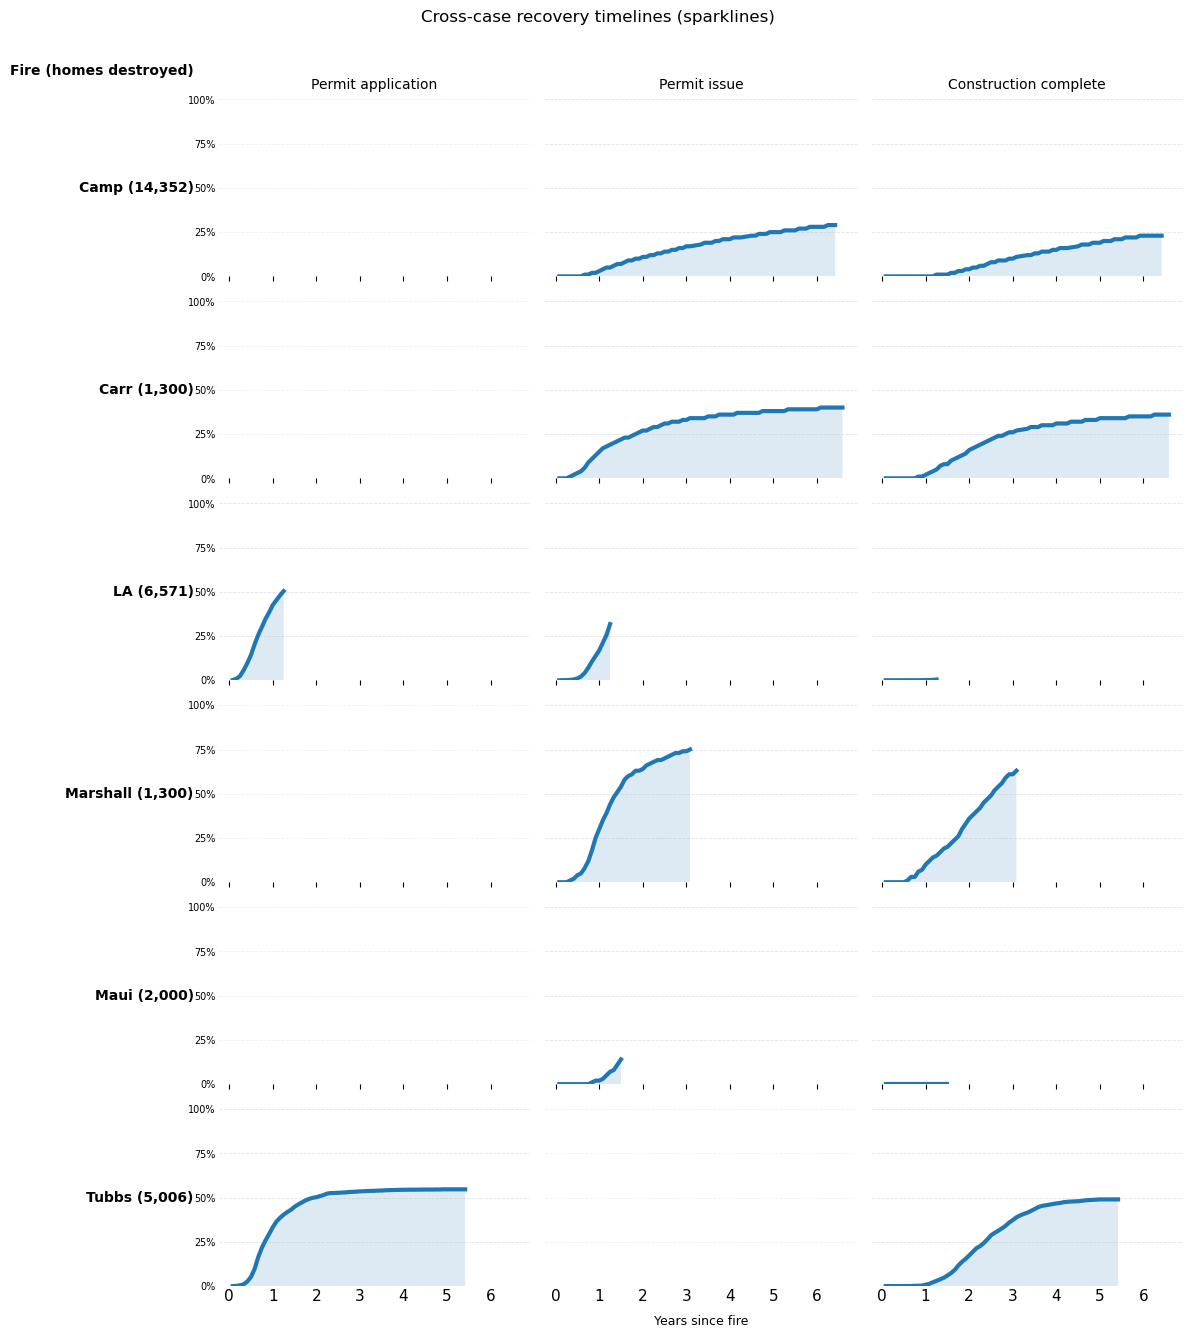

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Load the timeline data
csv_path = "Cross_case_recovery_timelines.csv"
df = pd.read_csv(csv_path)

# Identify timeline axis
x = df["Day"]

# Normalize milestone names so similar labels map together
MILESTONE_PATTERNS = {
    "Permit application": ["permit application"],
    "Permit issue": ["permit issue", "permits issued", "permit issued", "permitted"],
    "Construction complete": ["construction complete", "construction complete", "occupied"],
}

# Discover fire -> milestone columns from headers like "LA - Permit Application Received"
fire_map = {}
for col in df.columns:
    if " - " not in col:
        continue

    fire, metric = col.split(" - ", 1)
    metric_norm = metric.strip().lower()

    matched_milestone = None
    for milestone, patterns in MILESTONE_PATTERNS.items():
        if any(pattern in metric_norm for pattern in patterns):
            matched_milestone = milestone
            break

    if matched_milestone is None:
        continue

    fire_map.setdefault(fire, {})[matched_milestone] = col

fires = sorted(fire_map.keys())
milestones = ["Permit application", "Permit issue", "Construction complete"]

homes_destroyed = {
    "Camp": 14352,
    "Carr": 1300,
    "LA": 6571,
    "Marshall": 1300,
    "Maui": 2000,
    "Tubbs": 5006,
}

if not fires:
    raise ValueError("No fire/milestone columns were detected. Check CSV column names.")

# Build sparkline grid: one row per fire, milestone columns
fig, axes = plt.subplots(
    nrows=len(fires),
    ncols=len(milestones),
    figsize=(12, max(2.2 * len(fires), 4)),
    sharex=True,
)

# Handle single-row/single-column shape edge cases
if len(fires) == 1 and len(milestones) == 1:
    axes = [[axes]]
elif len(fires) == 1:
    axes = [axes]
elif len(milestones) == 1:
    axes = [[ax] for ax in axes]

for r, fire in enumerate(fires):
    for c, milestone in enumerate(milestones):
        ax = axes[r][c]
        ax.set_ylim(0, 100)
        col = fire_map[fire].get(milestone)

        if col is None:
            ax.set_xticks([])
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.2)
            for spine in ax.spines.values():
                spine.set_visible(False)
            if c == 0:
                ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=7)
                ax.tick_params(axis="y", length=0, pad=2)
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis="y", length=0)
            continue

        series = pd.to_numeric(df[col], errors="coerce")
        valid = series.notna()

        if valid.any():
            ax.plot(x[valid], series[valid], linewidth=3)
            ax.fill_between(x[valid], series[valid], alpha=0.15)

            # Add horizontal reference gridlines for percent readability
            ax.set_xticks([])
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)
            for spine in ax.spines.values():
                spine.set_visible(False)

            # Keep y-axis labels only in first milestone column
            if c == 0:
                ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=7)
                ax.tick_params(axis="y", length=0, pad=2)
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis="y", length=0)

        else:
            ax.set_xticks([])
            ax.set_yticks([0, 25, 50, 75, 100])
            ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.2)
            for spine in ax.spines.values():
                spine.set_visible(False)
            if c == 0:
                ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=7)
                ax.tick_params(axis="y", length=0, pad=2)
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis="y", length=0)

# Set column titles explicitly so they always appear
for c, milestone in enumerate(milestones):
    axes[0][c].set_title(milestone, fontsize=10, pad=8)

# Add fire labels (with total homes destroyed) on the left
for r, fire in enumerate(fires):
    destroyed = homes_destroyed.get(fire)
    fire_label = f"{fire} ({destroyed:,})" if destroyed is not None else fire

    axes[r][0].text(
        -0.08,
        0.5,
        fire_label,
        transform=axes[r][0].transAxes,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

# Column header for the fire-label column
axes[0][0].text(
    -0.08,
    1.12,
    "Fire (homes destroyed)",
    transform=axes[0][0].transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    fontweight="bold",
)

# Show year labels on x-axis for the bottom row
month_series = pd.to_numeric(df["Month"], errors="coerce")
year_series = month_series / 12.0

max_year = int(year_series.max()) if year_series.notna().any() else 0
tick_years = list(range(0, max_year + 1))

month_tick_positions = pd.Series(tick_years) * 30 * 12
month_tick_labels = [str(y) for y in tick_years]

for c in range(len(milestones)):
    ax = axes[-1][c]
    ax.set_xticks(month_tick_positions)
    ax.set_xticklabels(month_tick_labels, fontsize=11)
    ax.tick_params(axis="x", length=0, pad=2)

axes[-1][1].set_xlabel("Years since fire", fontsize=9, labelpad=8)

fig.suptitle("Cross-case recovery timelines (sparklines)", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

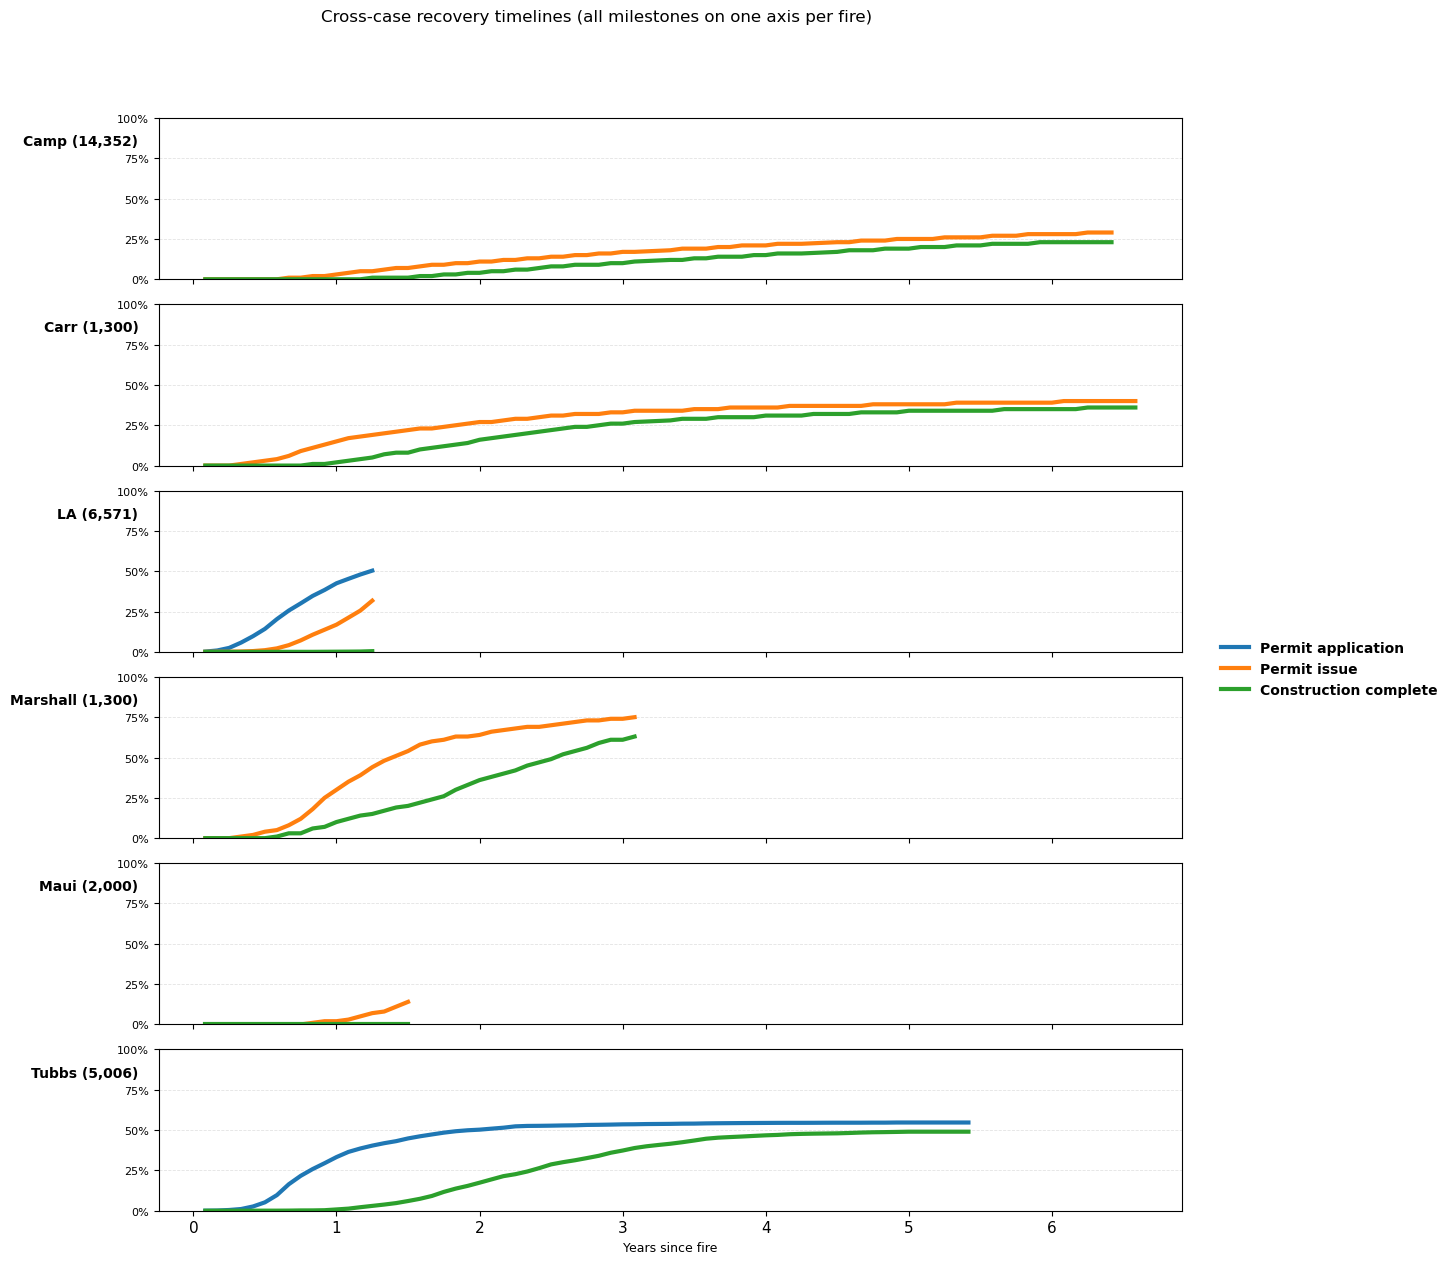

In [3]:
# Combined view: one axis per fire, all milestones overlaid
if "fires" not in globals() or "fire_map" not in globals() or "milestones" not in globals():
    raise ValueError("Run the previous cell first so fires/fire_map/milestones are available.")

fig, axes = plt.subplots(
    nrows=len(fires),
    ncols=1,
    figsize=(12, max(2.0 * len(fires), 4)),
    sharex=True,
    sharey=True,
)

if len(fires) == 1:
    axes = [axes]

colors = {
    "Permit application": "#1f77b4",
    "Permit issue": "#ff7f0e",
    "Construction complete": "#2ca02c",
}

for r, fire in enumerate(fires):
    ax = axes[r]
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

    for milestone in milestones:
        col = fire_map[fire].get(milestone)
        if col is None:
            continue

        series = pd.to_numeric(df[col], errors="coerce")
        valid = series.notna()
        if valid.any():
            ax.plot(
                x[valid],
                series[valid],
                linewidth=3,
                color=colors.get(milestone),
                label=milestone,
            )

    # Fire labels with homes destroyed
    destroyed = homes_destroyed.get(fire) if "homes_destroyed" in globals() else None
    fire_label = f"{fire} ({destroyed:,})" if destroyed is not None else fire
    ax.text(
        -0.02,
        0.9,
        fire_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        fontweight="bold",
    )

    # Keep y labels only once for readability
    if r == 0:
        ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=8)
    else:
        ax.tick_params(axis="y", labelsize=8)

# Years on x-axis
month_series = pd.to_numeric(df["Month"], errors="coerce")
year_series = month_series / 12.0
max_year = int(year_series.max()) if year_series.notna().any() else 0
tick_years = list(range(0, max_year + 1))

tick_positions = pd.Series(tick_years) * 30 * 12
for ax in axes:
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([str(y) for y in tick_years], fontsize=11)

axes[-1].set_xlabel("Years since fire", fontsize=9)

# Single legend for all milestone lines
legend_handles = [
    plt.Line2D([0], [0], color=colors[m], linewidth=3, label=m)
    for m in milestones
]
fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    prop={"weight": "bold"},
)

fig.suptitle("Cross-case recovery timelines (all milestones on one axis per fire)", y=1.05, fontsize=12)
plt.tight_layout()
plt.show()


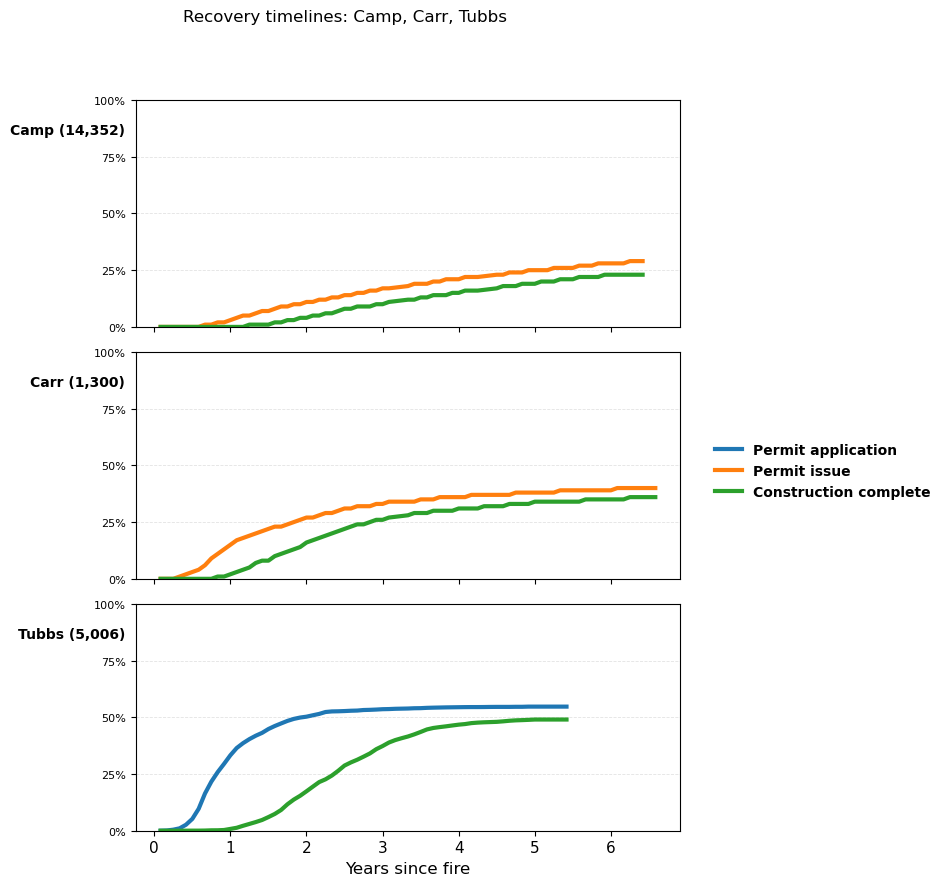

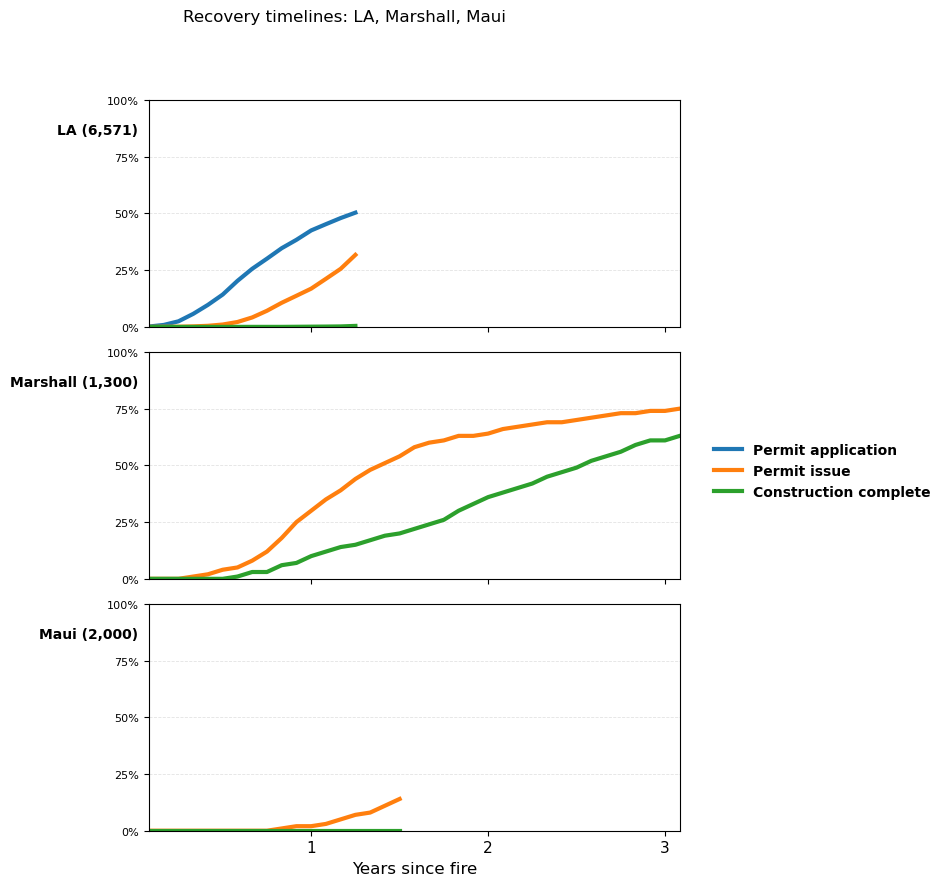

In [4]:
# Split into two figures with selected fire groups
if "fires" not in globals() or "fire_map" not in globals() or "milestones" not in globals():
    raise ValueError("Run the previous setup cell first so fires/fire_map/milestones are available.")

colors = {
    "Permit application": "#1f77b4",
    "Permit issue": "#ff7f0e",
    "Construction complete": "#2ca02c",
}

month_series = pd.to_numeric(df["Month"], errors="coerce")
year_series = month_series / 12.0
max_year = int(year_series.max()) if year_series.notna().any() else 0
tick_years = list(range(0, max_year + 1))
tick_positions = pd.Series(tick_years) * 30 * 12


def plot_fire_group(group_fires, title, remove_x_whitespace=False):
    fig, axes = plt.subplots(
        nrows=len(group_fires),
        ncols=1,
        figsize=(7, max(2.8 * len(group_fires), 5)),
        sharex=True,
        sharey=True,
    )

    if len(group_fires) == 1:
        axes = [axes]

    for r, fire in enumerate(group_fires):
        ax = axes[r]
        ax.set_ylim(0, 100)
        ax.set_yticks([0, 25, 50, 75, 100])
        ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.35)

        for milestone in milestones:
            col = fire_map.get(fire, {}).get(milestone)
            if col is None:
                continue

            series = pd.to_numeric(df[col], errors="coerce")
            valid = series.notna()
            if valid.any():
                ax.plot(
                    x[valid],
                    series[valid],
                    linewidth=3,
                    color=colors[milestone],
                    label=milestone,
                )

        destroyed = homes_destroyed.get(fire) if "homes_destroyed" in globals() else None
        fire_label = f"{fire} ({destroyed:,})" if destroyed is not None else fire
        ax.text(
            -0.02,
            0.9,
            fire_label,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            fontweight="bold",
        )

        if r == 0:
            ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontsize=8)
        else:
            ax.tick_params(axis="y", labelsize=8)

        ax.set_xticks(tick_positions)
        ax.set_xticklabels([str(y) for y in tick_years], fontsize=11)

    axes[-1].set_xlabel("Years since fire", fontsize=12)

    if remove_x_whitespace:
        # Tighten to the data range for this group (no padded x whitespace)
        x_mins = []
        x_maxs = []
        for fire in group_fires:
            for milestone in milestones:
                col = fire_map.get(fire, {}).get(milestone)
                if col is None:
                    continue
                series = pd.to_numeric(df[col], errors="coerce")
                valid = series.notna()
                if valid.any():
                    x_valid = x[valid]
                    x_mins.append(x_valid.min())
                    x_maxs.append(x_valid.max())

        if x_mins and x_maxs:
            group_xmin = min(x_mins)
            group_xmax = max(x_maxs)
            for ax in axes:
                ax.set_xlim(group_xmin, group_xmax)
                ax.margins(x=0)

    legend_handles = [
        plt.Line2D([0], [0], color=colors[m], linewidth=3, label=m)
        for m in milestones
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        prop={"weight": "bold"},
    )

    fig.suptitle(title, y=1.05, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_fire_group(["Camp", "Carr", "Tubbs"], "Recovery timelines: Camp, Carr, Tubbs")
plot_fire_group(
    ["LA", "Marshall", "Maui"],
    "Recovery timelines: LA, Marshall, Maui",
    remove_x_whitespace=True,
)


In [5]:
# PowerPoint prep: build checkpoint snapshots for each fire
import os
import numpy as np

checkpoint_months = [
    (3, "3 months"),
    (6, "6 months"),
    (9, "9 months"),
    (12, "12 months"),
    (24, "2 years"),
    (36, "3 years"),
    (None, "Full data"),
]

if "df" not in globals() or "fires" not in globals() or "fire_map" not in globals():
    raise ValueError("Run the earlier setup/plot cells first so df, fires, and fire_map exist.")

month_series = pd.to_numeric(df["Month"], errors="coerce")


def value_at_checkpoint(series, checkpoint_month):
    series_num = pd.to_numeric(series, errors="coerce")
    valid = series_num.notna() & month_series.notna()
    if not valid.any():
        return np.nan

    if checkpoint_month is None:
        return float(series_num[valid].iloc[-1])

    eligible = valid & (month_series <= checkpoint_month)
    if not eligible.any():
        return np.nan

    return float(series_num[eligible].iloc[-1])


checkpoint_data = {}
for checkpoint_month, checkpoint_label in checkpoint_months:
    rows = []
    for fire in fires:
        permit_col = fire_map.get(fire, {}).get("Permit issue")
        complete_col = fire_map.get(fire, {}).get("Construction complete")

        permit_val = (
            value_at_checkpoint(df[permit_col], checkpoint_month)
            if permit_col is not None
            else np.nan
        )
        complete_val = (
            value_at_checkpoint(df[complete_col], checkpoint_month)
            if complete_col is not None
            else np.nan
        )

        rows.append(
            {
                "Fire": fire,
                "Permit issue": permit_val,
                "Construction complete": complete_val,
            }
        )

    checkpoint_data[checkpoint_label] = pd.DataFrame(rows)

# Preview one checkpoint table
display(checkpoint_data["12 months"])


,Fire,Permit issue,Construction complete
0,Camp,3.000000,0.000000
1,Carr,15.000000,2.000000
2,LA,16.861969,0.106529
3,Marshall,30.000000,10.000000
4,Maui,2.000000,0.000000
5,Tubbs,NaN,0.799041


In [6]:
# Generate checkpoint images only (no PowerPoint)
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

output_dir = Path("Results") / "disaster_progress_slides"
output_dir.mkdir(parents=True, exist_ok=True)

# Fire order and labels for images (Tubbs removed)
slide_fire_order = ["Camp", "Carr", "Marshall", "Maui", "LA"]
slide_fire_order = [f for f in slide_fire_order if f in fires]
if not slide_fire_order:
    slide_fire_order = [f for f in fires if f != "Tubbs"]

fire_label_base = {
    "Camp": "2018 Camp (14,352)",
    "Carr": "2018 Carr (1,300)",
    "LA": "2025 LA (6,571)",
    "Marshall": "2021 Marshall (1,300)",
    "Maui": "2023 Maui (2,000)",
}

bar_colors = {
    "Permit issue": "#1f77b4",
    "Construction complete": "#2ca02c",
}


def faded_color(color_hex, fade_to_gray=0.65, gray_level=0.75):
    base_rgb = np.array(mcolors.to_rgb(color_hex))
    gray_rgb = np.array([gray_level, gray_level, gray_level])
    return tuple((1 - fade_to_gray) * base_rgb + fade_to_gray * gray_rgb)


ordered_checkpoints = [(m, label) for m, label in checkpoint_months if label in checkpoint_data]

# User-defined inactivity timing (in months)
inactive_after_months = {
    "LA": 12,
    "Maui": 12,
    "Marshall": 24,
}

data_month_notes = {
    "LA": 15,
    "Maui": 19,
    "Marshall": 37,
}

# Compute months of available data per fire (based on Permit issue or Construction complete)
fire_data_months = {}
month_numeric = pd.to_numeric(df["Month"], errors="coerce")
for fire in fires:
    permit_col = fire_map.get(fire, {}).get("Permit issue")
    complete_col = fire_map.get(fire, {}).get("Construction complete")

    valid_any = pd.Series(False, index=df.index)
    if permit_col is not None:
        valid_any = valid_any | pd.to_numeric(df[permit_col], errors="coerce").notna()
    if complete_col is not None:
        valid_any = valid_any | pd.to_numeric(df[complete_col], errors="coerce").notna()

    valid_months = month_numeric[valid_any & month_numeric.notna()]
    fire_data_months[fire] = int(valid_months.max()) if not valid_months.empty else 0

image_paths = []
for checkpoint_month, checkpoint_label in ordered_checkpoints:
    checkpoint_df = checkpoint_data[checkpoint_label]
    plot_df = checkpoint_df[checkpoint_df["Fire"] != "Tubbs"]
    plot_df = plot_df.set_index("Fire").reindex(slide_fire_order).reset_index()

    active_rows = []
    for fire in plot_df["Fire"]:
        if fire == "Marshall" and checkpoint_label == "3 years":
            active_rows.append(True)
            continue

        threshold = inactive_after_months.get(fire)
        if threshold is None or checkpoint_month is None:
            active_rows.append(True)
        else:
            active_rows.append(checkpoint_month <= threshold)

    active_mask = np.array(active_rows, dtype=bool)

    permit_colors = [
        bar_colors["Permit issue"] if active else faded_color(bar_colors["Permit issue"])
        for active in active_mask
    ]
    complete_colors = [
        bar_colors["Construction complete"] if active else faded_color(bar_colors["Construction complete"])
        for active in active_mask
    ]

    permit_vals_raw = plot_df["Permit issue"].values
    complete_vals_raw = plot_df["Construction complete"].values
    permit_vals = plot_df["Permit issue"].fillna(0).values
    complete_vals = plot_df["Construction complete"].fillna(0).values

    y = np.arange(len(plot_df))
    bar_h = 0.36

    fig, ax = plt.subplots(figsize=(11, 6.2))
    ax.barh(
        y - bar_h / 2,
        permit_vals,
        height=bar_h,
        color=permit_colors,
        label="Permit issue",
    )
    ax.barh(
        y + bar_h / 2,
        complete_vals,
        height=bar_h,
        color=complete_colors,
        label="Construction complete",
    )

    y_labels = []
    for fire, active in zip(plot_df["Fire"], active_mask):
        base_label = fire_label_base.get(fire, fire)
        if checkpoint_label == "Full data":
            y_labels.append(f"{base_label} | {fire_data_months.get(fire, 0)} mo data")
        elif (not active) and (fire in data_month_notes):
            y_labels.append(f"{base_label} | {data_month_notes[fire]} mo data")
        else:
            y_labels.append(base_label)

    ax.set_xlim(0, 100)
    ax.set_yticks(y)
    ax.set_yticklabels(y_labels, fontsize=15, fontweight="bold")
    ax.set_xlabel("Percent of homes", fontsize=15, fontweight="bold")
    ax.tick_params(axis="x", labelsize=13)
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    legend_handles = [
        Patch(facecolor=bar_colors["Permit issue"], label="Permit issue"),
        Patch(facecolor=bar_colors["Construction complete"], label="Construction complete"),
        Patch(facecolor=faded_color("#7f7f7f", fade_to_gray=0.2, gray_level=0.85), label="Inactive"),
    ]
    ax.legend(handles=legend_handles, loc="lower right", prop={"weight": "bold", "size": 13})

    # Label values at bar ends
    for i, (p_raw, c_raw, p, c, active) in enumerate(
        zip(permit_vals_raw, complete_vals_raw, permit_vals, complete_vals, active_mask)
    ):
        text_color = "black" if active else "#6b6b6b"
        if pd.notna(p_raw):
            ax.text(min(p + 1, 99), i - bar_h / 2, f"{p:.1f}%", va="center", fontsize=12, color=text_color)
        if pd.notna(c_raw):
            ax.text(min(c + 1, 99), i + bar_h / 2, f"{c:.1f}%", va="center", fontsize=12, color=text_color)

    ax.invert_yaxis()
    plt.tight_layout()

    img_path = output_dir / f"progress_{checkpoint_label.replace(' ', '_')}.png"
    fig.savefig(img_path, dpi=220)
    plt.close(fig)
    image_paths.append((checkpoint_label, img_path))

print("Images created:")
for label, path in image_paths:
    print(f"- {label}: {path}")


Images created:
- 3 months: Results/disaster_progress_slides/progress_3_months.png
- 6 months: Results/disaster_progress_slides/progress_6_months.png
- 9 months: Results/disaster_progress_slides/progress_9_months.png
- 12 months: Results/disaster_progress_slides/progress_12_months.png
- 2 years: Results/disaster_progress_slides/progress_2_years.png
- 3 years: Results/disaster_progress_slides/progress_3_years.png
- Full data: Results/disaster_progress_slides/progress_Full_data.png


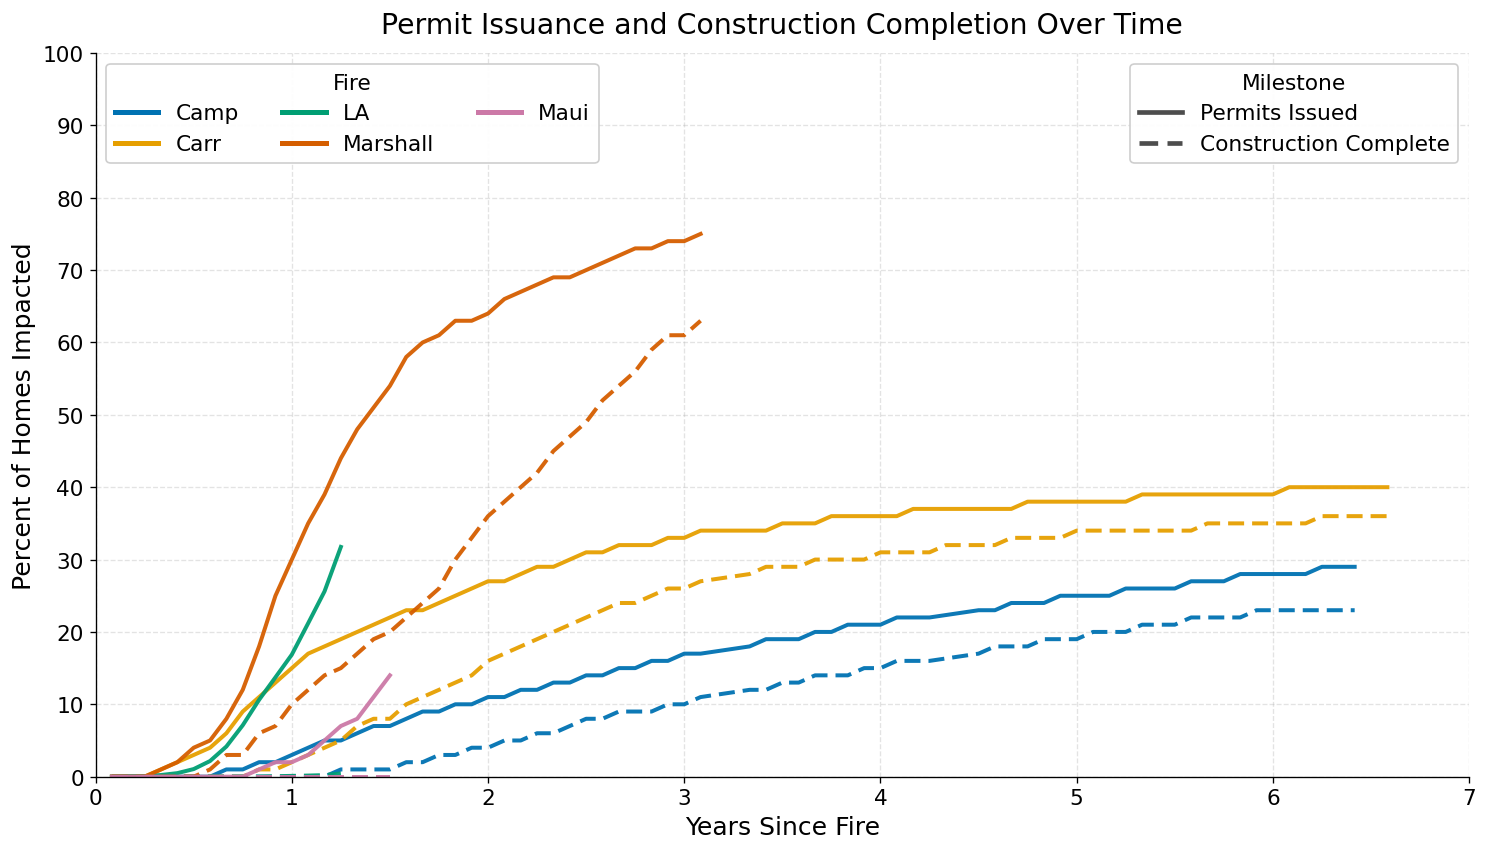

In [19]:
# Improved comparison plot: one color per fire, one line style per milestone
import numpy as np
from matplotlib.lines import Line2D

# Reset any previous global style/font changes in the notebook session
plt.rcdefaults()

required_fires = ["Camp", "Carr", "LA", "Marshall", "Maui"]

if "df" not in globals() or "fire_map" not in globals():
    raise ValueError("Run the previous setup cells first so df and fire_map are available.")

month_vals = pd.to_numeric(df["Month"], errors="coerce")
year_vals = month_vals / 12.0

labels = {
    "Camp": "Camp",
    "Carr": "Carr",
    "LA": "LA",
    "Marshall": "Marshall",
    "Maui": "Maui",
}

# Colorblind-friendly palette with stronger contrast
fire_colors = {
    "Camp": "#0072B2",
    "Carr": "#E69F00",
    "LA": "#009E73",
    "Marshall": "#D55E00",
    "Maui": "#CC79A7",
}

fig, ax = plt.subplots(figsize=(12.5, 7.2), dpi=120)

for fire in required_fires:
    if fire not in fire_map:
        continue

    color = fire_colors.get(fire, "#4d4d4d")

    permit_col = fire_map[fire].get("Permit issue")
    complete_col = fire_map[fire].get("Construction complete")

    if permit_col is not None and permit_col in df.columns:
        y_permit = pd.to_numeric(df[permit_col], errors="coerce")
        valid_permit = year_vals.notna() & y_permit.notna()
        x_perm = year_vals[valid_permit].to_numpy()
        y_perm = y_permit[valid_permit].to_numpy()
        if len(x_perm) > 0:
            order = np.argsort(x_perm)
            x_perm, y_perm = x_perm[order], y_perm[order]
            ax.plot(
                x_perm,
                y_perm,
                color=color,
                linewidth=2.4,
                linestyle="-",
                alpha=0.95,
            )

    if complete_col is not None and complete_col in df.columns:
        y_complete = pd.to_numeric(df[complete_col], errors="coerce")
        valid_complete = year_vals.notna() & y_complete.notna()
        x_comp = year_vals[valid_complete].to_numpy()
        y_comp = y_complete[valid_complete].to_numpy()
        if len(x_comp) > 0:
            order = np.argsort(x_comp)
            x_comp, y_comp = x_comp[order], y_comp[order]
            ax.plot(
                x_comp,
                y_comp,
                color=color,
                linewidth=2.4,
                linestyle=(0, (4, 2)),
                alpha=0.95,
            )

# Axis formatting
x_max = float(np.nanmax(year_vals.to_numpy())) if year_vals.notna().any() else 0
x_upper = int(np.ceil(max(1, x_max)))
ax.set_xlim(0, x_upper)
ax.set_ylim(0, 100)
ax.set_xticks(np.arange(0, x_upper + 1, 1))
ax.set_yticks(np.arange(0, 101, 10))

# Larger typography for all plot text
axis_label_size = 15
title_size = 17
tick_label_size = 13
legend_text_size = 13
legend_title_size = 13

ax.set_xlabel("Years Since Fire", fontsize=axis_label_size)
ax.set_ylabel("Percent of Homes Impacted", fontsize=axis_label_size)
ax.set_title("Permit Issuance and Construction Completion Over Time", fontsize=title_size, pad=12)
ax.tick_params(axis="both", labelsize=tick_label_size)

# Cleaner, softer grid and frame
ax.grid(True, axis="both", linestyle="--", linewidth=0.8, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Two concise legends: color encodes fire, line style encodes milestone
fire_handles = [
    Line2D([0], [0], color=fire_colors[f], lw=3, label=labels[f])
    for f in required_fires
    if f in fire_colors
]
style_handles = [
    Line2D([0], [0], color="#4d4d4d", lw=2.8, linestyle="-", label="Permits Issued"),
    Line2D([0], [0], color="#4d4d4d", lw=2.8, linestyle=(0, (4, 2)), label="Construction Complete"),
]

legend_fires = ax.legend(
    handles=fire_handles,
    title="Fire",
    ncol=3,
    loc="upper left",
    frameon=True,
    framealpha=0.95,
    fontsize=legend_text_size,
    title_fontsize=legend_title_size,
)
ax.add_artist(legend_fires)
ax.legend(
    handles=style_handles,
    title="Milestone",
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    fontsize=legend_text_size,
    title_fontsize=legend_title_size,
)

plt.tight_layout()
plt.show()